# Inventory Organizational Content

Code adapted to C3 org from the following documentation link: `https://developers.arcgis.com/python/latest/samples/inventory-organizational-content/`

In [ ]:
import pandas as pd
from IPython.display import display

import arcgis
from arcgis.gis import GIS

#### Connect to ArcGIS Online

<User username:aolson_c3>
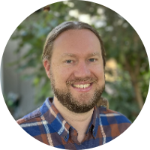

In [2]:
c3GIS = GIS(profile='aolson_prfl2')
c3GIS.users.me

## Querying Content

In [7]:
# query = f"owner: {c3GIS.users.me.username}"
# query = f"owner: aolson_c3_test"
query = f"owner: aolson_c3_test_2"

user_content_cnt = c3GIS.content.advanced_search(query=query,return_count=True)
print(user_content_cnt, 'items found for user')

6 items found for user


### Searching for Content

In [10]:
query = f"owner: {c3GIS.users.me.username}"
# max_items = 9000 #ITS OVER 9000!!!!!!
max_items = 3

user_content = c3GIS.content.advanced_search(query=query, max_items=max_items)
user_content

{'total': 82,
 'start': 1,
 'num': 3,
 'nextStart': 4,
 'results': [<Item title:"(Internal) Commerce City Active Development Web Application" type:Web Experience owner:aolson_c3>,
  <Item title:"Access C3 Encampment Reports" type:Web Map owner:aolson_c3>,
  <Item title:"Active Development GDB" type:File Geodatabase owner:aolson_c3>]}

### Displaying Content

<Item title:"(Internal) Commerce City Active Development Web Application" type:Web Experience owner:aolson_c3>
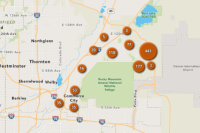

<Item title:"Access C3 Encampment Reports" type:Web Map owner:aolson_c3>
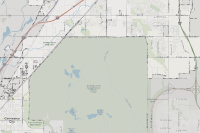

<Item title:"Active Development GDB" type:File Geodatabase owner:aolson_c3>
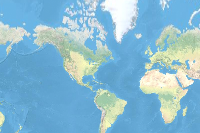

In [11]:
for item in user_content['results']:
    display(item)

### Return items as a dictionary with as_dict=True

In [13]:
user_content_as_dict = c3GIS.content.advanced_search(query=query,max_items=max_items,
                                                     as_dict=True)
user_content_as_dict['results']

[{'id': 'e282bc55a3e04fe58447ba3e2e441cd5',
  'owner': 'aolson_c3',
  'orgId': 'iyZLRarIZZa0GHya',
  'created': 1741275157000,
  'isOrgItem': True,
  'modified': 1775167302000,
  'guid': None,
  'name': None,
  'title': '(Internal) Commerce City Active Development Web Application',
  'type': 'Web Experience',
  'typeKeywords': ['Copy Item',
   'EXB Experience',
   'JavaScript',
   'modified: 1762451076646',
   'publishVersion:1.17.0',
   'Ready To Use',
   'status: Published',
   'version:1.19.0',
   'Web Application',
   'Web Experience',
   'Web Mapping Application',
   'Web Page',
   'Web Site'],
  'description': "<p>The Commerce City Active Development App displays City project and permit data on a map. Data for projects and permits is publicly available on the Commerce City Permitting and Land Use Portal commonly called eTRAKiT:&nbsp;<a target='_blank' href='https://comc.csqrcloud.com/community-etrakit/' rel='nofollow ugc noopener noreferrer'>Permitting and Land Use Portal</a></p>

### Sorting Content

<Item title:"SeeClickFix Encampment Report" type:Feature Layer Collection owner:aolson_c3>
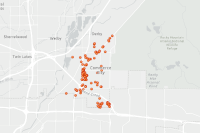

<Item title:"SeeClickFix Encampment Report" type:File Geodatabase owner:aolson_c3>

<Item title:"Active Development GDB" type:Feature Layer Collection owner:aolson_c3>
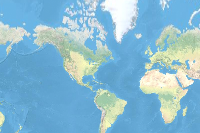

In [14]:
content_last_modified = c3GIS.content.advanced_search(query=query,max_items=max_items,
                                                      sort_field="modified", sort_order="desc")

for item in content_last_modified['results']:
    display(item)

<Item title:"What's New C3 - Come Tour Development with Us" type:Web Experience owner:aolson_c3>
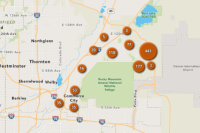

<Item title:"Global Drought Risk AO" type:Web Experience owner:aolson_c3>
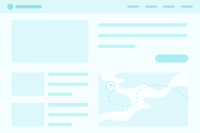

<Item title:"Rio Grande Dashboard AO" type:Web Experience owner:aolson_c3>
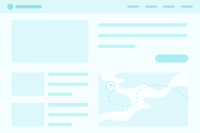

In [15]:
content_first_created = c3GIS.content.advanced_search(query=query, max_items=max_items,
                                                     sort_field="created", sort_order="asc")

for item in content_first_created['results']:
    display(item)


## Querying Organization Content

### Searching for Organization Members

In [16]:
# View UserManager object
c3GIS.users

< UserManager at https://c3.maps.arcgis.com >

In [22]:
org_users = c3GIS.users.search(max_users=9000) #Default return limit is 100, bump it up to 9000!!!!!!!
print(f'{len(org_users)} users found')
org_users[:3]

289 users found


[<User username:aarmentamarquez_c3>,
 <User username:abeasley_c3>,
 <User username:abriggs_c3>]

In [23]:
# Display 2nd member
org_member = org_users[1]
org_member

<User username:abeasley_c3>

### Getting Member Content

In [27]:
# See the number of member items, set return_count=True for all items.
query = "owner: " + org_member.username

member_content_count = c3GIS.content.advanced_search(query=query, 
                                                     return_count=True)

print(f'Org member has {member_content_count} items')


Org member has 0 items


### Compiling Organization Content

In [28]:
# Return content for each user in org, compile into single snapshot

org_content = []

for user in org_users:
    query = f'owner: {user.username}'
    user_content = c3GIS.content.advanced_search(query=query, max_items=9000)['results']
    org_content += user_content

print(f'{len(org_content)} items found in org')

1043 items found in org


## Analyzing Organization Content with Pandas

In [30]:
# Create dataframe
content_df = pd.DataFrame(org_content)

content_df.head()

,id,owner,orgId,created,isOrgItem,modified,guid,name,title,type,...,groupDesignations,apiToken1ExpirationDate,apiToken2ExpirationDate,contentOrigin,lastViewed,size,commentsEnabled,itemControl,layers,tables
0,e282bc55a3e04fe58447ba3e2e441cd5,aolson_c3,iyZLRarIZZa0GHya,1741275157000,True,1775167302000,None,None,(Internal) Commerce City Active Development We...,Web Experience,...,None,-1,-1,self,1777932000000,895678.0,True,admin,NaN,NaN
1,39ef2fa4a07d42738794416d66e61bd3,aolson_c3,iyZLRarIZZa0GHya,1764975466000,True,1770935709000,None,None,Access C3 Encampment Reports,Web Map,...,None,-1,-1,self,1778094000000,NaN,NaN,NaN,NaN,NaN
2,87854ebdf0394f91851a88f8edbb7404,aolson_c3,iyZLRarIZZa0GHya,1741300304000,True,1777908084000,None,Active_Development_hosted.zip,Active Development GDB,File Geodatabase,...,None,-1,-1,self,1777906800000,NaN,NaN,NaN,NaN,NaN
3,24f74535442f45e5a525504eb2e9e53b,aolson_c3,iyZLRarIZZa0GHya,1741300306000,True,1777908130000,None,None,Active Development GDB,Feature Service,...,None,-1,-1,self,1777932000000,NaN,NaN,NaN,NaN,NaN
4,b5d9c6f65b5d45b69713b660e55de934,aolson_c3,iyZLRarIZZa0GHya,1740596038000,True,1775250505000,None,None,Active Development Tracker Symbols,Style,...,None,-1,-1,self,1775509200000,NaN,NaN,NaN,NaN,NaN


In [31]:
# Use value_counts() to see how many items you have with a particular key:value pair
content_df.type.value_counts().head(10) # Return top 10 most frequent item types

type
Feature Service            209
Web Map                    204
Web Mapping Application    162
PDF                         87
Service Definition          77
Map Service                 55
CAD Drawing                 52
Web Experience              34
Shapefile                   20
File Geodatabase            18
Name: count, dtype: int64

In [32]:
# Summary count of all types in org
content_df.type.value_counts()

type
Feature Service                 209
Web Map                         204
Web Mapping Application         162
PDF                              87
Service Definition               77
Map Service                      55
CAD Drawing                      52
Web Experience                   34
Shapefile                        20
File Geodatabase                 18
Dashboard                        14
Microsoft Excel                  12
Form                             12
Code Attachment                   9
Image Service                     8
Notebook                          6
StoryMap                          6
Administrative Report             6
Image                             5
Project Package                   5
WMS                               5
Hub Site Application              4
Desktop Application Template      4
Web Experience Template           3
KML                               3
Application                       2
Mobile Map Package                2
Web Scene              

In [34]:
# Summary count of owner item content
content_df.owner.value_counts()

owner
rwoolf_c3               100
asinger_c3              100
bphetteplace_c3         100
C3_GIS_Admin            100
jmoening_c3             100
jallen_c3               100
mcampe_c3               100
wnafziger_c3             94
aolson_c3                82
dgibson_c3               44
aperalta_c3              40
nflock_c3                19
lcahill_c3               18
dmartinelli_c3           11
aolson_c3_Test_2          6
viewpro_commercecity      5
gisadmin_c3               3
lnordholt_c3              3
restrada_c3               2
snachtman_c3              2
yuprety_c3                2
ganderson_c3              2
mbonano_c3                1
nhougland_c3              1
hrenteria_c3              1
rholland_c3               1
etart_c3                  1
tcrider_c3                1
tferguson_c3              1
cmaciel_c3                1
cbustillos_c3             1
klor_c3                   1
Name: count, dtype: int64

In [35]:
# Count the items by access levels for org
content_df.access.value_counts()

access
private    468
org        249
public     166
shared     160
Name: count, dtype: int64

In [36]:
# Group item types by user
content_df.groupby('owner').type.value_counts().head(10)

owner         type                   
C3_GIS_Admin  Web Map                    30
              Map Service                26
              Feature Service            13
              Web Mapping Application     9
              Service Definition          5
              Image Service               4
              Application                 2
              Dashboard                   2
              File Geodatabase            2
              Hub Site Application        2
Name: count, dtype: int64

In [43]:
# Viewing the number of items per access level within the org
content_df.groupby('type').access.value_counts().head(10)

type                   access 
Administrative Report  private     6
Application            private     2
CAD Drawing            private    38
                       shared     14
CSV Collection         private     1
Code Attachment        private     5
                       org         2
                       public      2
Dashboard              private     9
                       org         2
Name: count, dtype: int64

## Filtering the Dataset

In [44]:
# Choose which fields to view in table and the order to view them in
view_columns = ['id','title','owner','type','access']
content_df[view_columns].head()

,id,title,owner,type,access
0,e282bc55a3e04fe58447ba3e2e441cd5,(Internal) Commerce City Active Development We...,aolson_c3,Web Experience,org
1,39ef2fa4a07d42738794416d66e61bd3,Access C3 Encampment Reports,aolson_c3,Web Map,public
2,87854ebdf0394f91851a88f8edbb7404,Active Development GDB,aolson_c3,File Geodatabase,private
3,24f74535442f45e5a525504eb2e9e53b,Active Development GDB,aolson_c3,Feature Service,org
4,b5d9c6f65b5d45b69713b660e55de934,Active Development Tracker Symbols,aolson_c3,Style,org


### Creating boolean masks

In [45]:
# Creating a mask to represent all items with public level access
filter_value = 'public'
filter_column = 'access'
row_filter = content_df[filter_column]==filter_value
row_filter.head() #Not very informative result


0    False
1     True
2    False
3    False
4    False
Name: access, dtype: bool

In [47]:
# Applying this mask to the dataframe will return all fields for objects which have access='public'
print(len(content_df[row_filter]), 'objects in filtered dataframe')
content_df[row_filter].head()


166 objects in filtered dataframe


,id,owner,orgId,created,isOrgItem,modified,guid,name,title,type,...,groupDesignations,apiToken1ExpirationDate,apiToken2ExpirationDate,contentOrigin,lastViewed,size,commentsEnabled,itemControl,layers,tables
1,39ef2fa4a07d42738794416d66e61bd3,aolson_c3,iyZLRarIZZa0GHya,1764975466000,True,1770935709000,None,None,Access C3 Encampment Reports,Web Map,...,None,-1,-1,self,1778094000000,NaN,NaN,NaN,NaN,NaN
6,f1ad9eb2641d426ebd6e2c77babd89a7,aolson_c3,iyZLRarIZZa0GHya,1740671343000,True,1763675254000,None,None,Active Development Under Construction,Feature Service,...,None,-1,-1,self,1778097600000,NaN,NaN,NaN,NaN,NaN
7,d9bce4a66ac94160b57eefd67362f736,aolson_c3,iyZLRarIZZa0GHya,1709594816000,True,1775513177000,None,None,Active Development Under Construction,Web Map,...,None,-1,-1,self,1778097600000,NaN,NaN,NaN,NaN,NaN
13,23a96428fa6f4e85ac081a1a59c4a29d,aolson_c3,iyZLRarIZZa0GHya,1740676008000,True,1775513233000,None,None,Active Development Under Review,Web Map,...,None,-1,-1,self,1778097600000,NaN,NaN,NaN,NaN,NaN
14,ee3475f52d8241aa9f365b54337ac81f,aolson_c3,iyZLRarIZZa0GHya,1740671877000,True,1763675226000,None,None,Active Development Under Review,Feature Service,...,None,-1,-1,self,1778097600000,NaN,NaN,NaN,NaN,NaN


In [48]:
# Apply the column filter and the Boolean mask to reduce the amount of information displayed.
content_df[row_filter][view_columns].head()

,id,title,owner,type,access
1,39ef2fa4a07d42738794416d66e61bd3,Access C3 Encampment Reports,aolson_c3,Web Map,public
6,f1ad9eb2641d426ebd6e2c77babd89a7,Active Development Under Construction,aolson_c3,Feature Service,public
7,d9bce4a66ac94160b57eefd67362f736,Active Development Under Construction,aolson_c3,Web Map,public
13,23a96428fa6f4e85ac081a1a59c4a29d,Active Development Under Review,aolson_c3,Web Map,public
14,ee3475f52d8241aa9f365b54337ac81f,Active Development Under Review,aolson_c3,Feature Service,public


In [49]:
# Create a Boolean mask for object type "Web Map"
filter_value = 'Web Map'
filter_column = 'type'
row_filter = content_df[filter_column]==filter_value
content_df[row_filter][view_columns]

,id,title,owner,type,access
1,39ef2fa4a07d42738794416d66e61bd3,Access C3 Encampment Reports,aolson_c3,Web Map,public
7,d9bce4a66ac94160b57eefd67362f736,Active Development Under Construction,aolson_c3,Web Map,public
8,4fecb39872394580a411d76bf476bf89,Active Development Under Construction (Backup ...,aolson_c3,Web Map,private
9,80ac2aab4b294622b9ceab8af60ecd72,Active Development Under Construction (INTERNAL),aolson_c3,Web Map,org
10,9bd25249fd6b47649fe3d4279ac0c0aa,Active Development Under Construction (Original),aolson_c3,Web Map,private
...,...,...,...,...,...
929,ad1258e06b2c4107a59c2fa4f581060b,METRO DISTRICTS BASEMAP-Copy,rwoolf_c3,Web Map,private
934,8513b0f71e174f1f98470855396e2322,Northern Range Certificate of Occupancy 2010 -...,rwoolf_c3,Web Map,public
940,ec3bf7f20dfb478d81f703e97c0410da,East_Med,tcrider_c3,Web Map,private
941,dd37beb4ffd44c339fe9f5d71f92fe7d,Second Creek Community Park,tferguson_c3,Web Map,private


In [50]:
# Boolean masks can also be combined to represent multiple filters. Here is the Web Map and Public masks combined to return all public web maps in the org
web_map_filter = content_df.type=='Web Map'
public_filter = content_df.access=='public'
combined_mask = web_map_filter & public_filter

content_df[combined_mask][view_columns]

,id,title,owner,type,access
1,39ef2fa4a07d42738794416d66e61bd3,Access C3 Encampment Reports,aolson_c3,Web Map,public
7,d9bce4a66ac94160b57eefd67362f736,Active Development Under Construction,aolson_c3,Web Map,public
13,23a96428fa6f4e85ac081a1a59c4a29d,Active Development Under Review,aolson_c3,Web Map,public
27,3f118c83aadc48d6af48e47e0d71d46d,CIPP Tracking Report Web Map,aolson_c3,Web Map,public
51,260ce4cc707c4ab19ef51d27c56a5396,Mowing All Weeks,aolson_c3,Web Map,public
53,9f4171395ff0484494ad8184d492b0b8,Mowing Week 1,aolson_c3,Web Map,public
54,f3ed0e05a2704a37bf06e13d72fd6722,Mowing Week 2,aolson_c3,Web Map,public
55,7b7b08ddd8704eb5bd63c6c1231d318b,Mowing Week 3,aolson_c3,Web Map,public
329,97df3f2677294d068d42c29cc2623e7f,2K CIP Project Basemap n Operational Layers,C3_GIS_Admin,Web Map,public
330,2e03316f0820452da6fb7af94e0f2754,2K CIP Project Basemap n Operational Layers-wo...,C3_GIS_Admin,Web Map,public


In [51]:
# Creating masks with the .apply() and lambda functions to find all types that end with text string 'Service'
service_filter = content_df.type.apply(lambda x : x.endswith('Service'))
content_df[service_filter][view_columns]

,id,title,owner,type,access
3,24f74535442f45e5a525504eb2e9e53b,Active Development GDB,aolson_c3,Feature Service,org
6,f1ad9eb2641d426ebd6e2c77babd89a7,Active Development Under Construction,aolson_c3,Feature Service,public
12,b6d30ca7f590476890e318cbfd4036ad,Active Development Under Construction Map Service,aolson_c3,Map Service,private
14,ee3475f52d8241aa9f365b54337ac81f,Active Development Under Review,aolson_c3,Feature Service,public
19,2095b3868e6a43bcbf3efc1c529ba71b,Active Development Under Review Map Service,aolson_c3,Map Service,private
...,...,...,...,...,...
1018,206b6ac15c8940828c32fbfc8b31b110,Northern Range Retail Profile Layers,wnafziger_c3,Feature Service,org
1019,695afdb8af7e4cc58e1b15f972778813,Northern Range West of E 470 Layers,wnafziger_c3,Feature Service,org
1024,5d8933850083460bad03c7b383d9374c,Northfield and Quebec Layers,wnafziger_c3,Feature Service,org
1029,c501aff704a24080b1d3af293e29261f,Northfield Shopping Center Layers,wnafziger_c3,Feature Service,org


## Accessing Content by ID

In [52]:
# Return the index of the last item in the previous output
# In this example the index column is labelled 'name'

target_index = content_df[service_filter].iloc[-1].name
print('Target Index:', target_index)

Target Index: 1033


In [54]:
# Accessing items with content.get()
target_data = content_df.loc[target_index]
print(target_data.id)
target_content = c3GIS.content.get(target_data.id)
target_content

22b0ebbb76ba412ebc47bf501ceb48b6


<Item title:"Opportunity Zone 89.01 Layers" type:Feature Layer Collection owner:wnafziger_c3>

## Exporting Data

In [57]:
# Exporting data to a csv
target_path = 'org_content.csv'
content_df.to_csv(target_path)

In [58]:
# Exporting data to gzipped csv file
target_path_gzip = 'org_content.csv.gz'
content_df.to_csv(target_path_gzip)

In [59]:
# Exporting data to zipped csv file
target_path_zip = 'org_content.csv.zip'
content_df.to_csv(target_path_zip)